In [2]:
import sys
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install opencv-python

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.listdir('/content/drive/MyDrive')

['Classroom',
 'Photo_1708669328218.jpg',
 'Photo_1708670394574.png',
 'ffssdd.gdoc',
 'Colab Notebooks',
 'Scanned_20250330-2117.pdf',
 'Scanned_20250331-1409.pdf',
 'ChatGPT Image May 20, 2025, 09_34_28 PM.png',
 'Untitled document (1).gdoc',
 'Untitled document.gdoc',
 'archive (2)',
 'M.Lucky(1).pdf',
 'Untitled form.gform',
 'Seminar Hall Booking System.gsheet',
 'data (1).csv',
 'allmarksheets.pdf',
 'visdrone_dataset.zip',
 'best_sahi_model.pt',
 'best_model_v3.pt',
 'runs',
 'sample_output',
 'detection',
 'visdrone_clean.zip',
 'pneumonia_detection',
 'archive (6).zip']

In [5]:
!unzip "/content/drive/MyDrive/archive (6).zip"

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [6]:
import os
os.listdir('/content')

['.config', 'seg_test', 'seg_pred', 'drive', 'seg_train', 'sample_data']

In [7]:
import os
os.listdir('/content/seg_train/seg_train')

['sea', 'mountain', 'street', 'glacier', 'buildings', 'forest']

In [24]:
train_dir = "/content/seg_train/seg_train"
test_dir = "/content/seg_test/seg_test"

In [9]:
os.listdir(train_dir)

['sea', 'mountain', 'street', 'glacier', 'buildings', 'forest']

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

/tmp/ipykernel_206/632844194.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

/tmp/ipykernel_206/402412482.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [16]:
num_classes = train_data.num_classes

x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
print(train_data.class_indices)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

/tmp/ipykernel_206/3016543445.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [32]:
for layer in base_model.layers:
    layer.trainable = False

In [33]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [34]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.7815 - loss: 0.6034 - val_accuracy: 0.8867 - val_loss: 0.2995
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9101 - loss: 0.2605 - val_accuracy: 0.8943 - val_loss: 0.2779
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9134 - loss: 0.2386 - val_accuracy: 0.8917 - val_loss: 0.2877
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9288 - loss: 0.2073 - val_accuracy: 0.8993 - val_loss: 0.2706
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9284 - loss: 0.2019 - val_accuracy: 0.8880 - val_loss: 0.2932


In [36]:
model.save("scene_classification_model.h5")

In [37]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [43]:
import os
os.listdir("/content/seg_test/seg_test/forest")[:10]

['21604.jpg',
 '22973.jpg',
 '23070.jpg',
 '22096.jpg',
 '23244.jpg',
 '24072.jpg',
 '22149.jpg',
 '24005.jpg',
 '23853.jpg',
 '23817.jpg']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Class: forest


(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

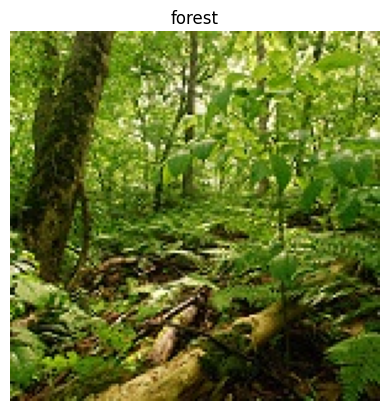

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img("/content/seg_test/seg_test/forest/23817.jpg", target_size=(150,150))

img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

plt.imshow(img)
plt.title(predicted_class)
plt.axis("off")

In [48]:
model.save("scene_classification_model.h5")

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step


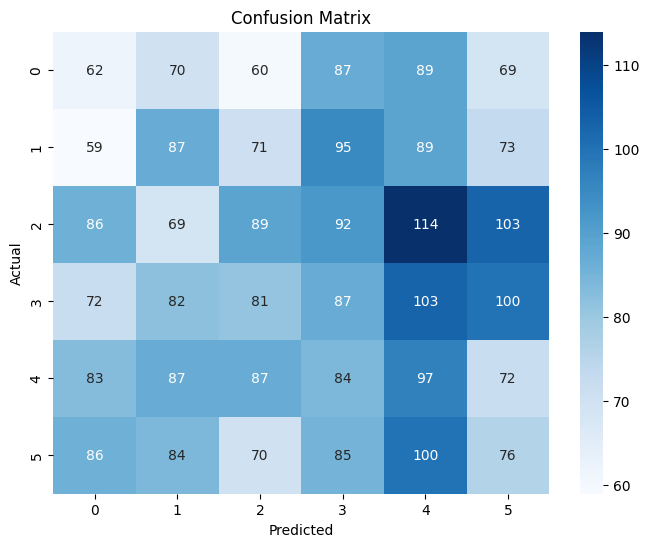

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_true = test_data.classes
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

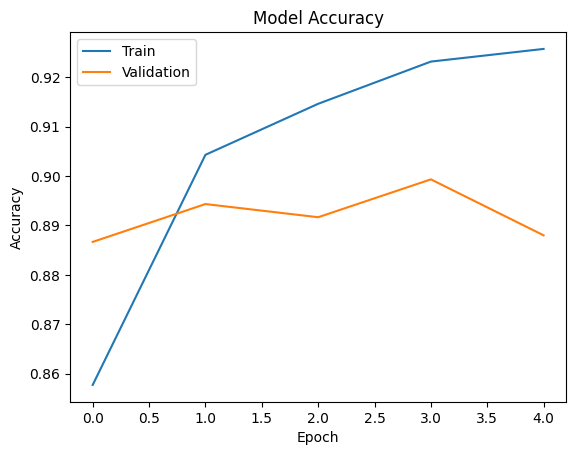

In [50]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.savefig("accuracy_graph.png")

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=list(train_data.class_indices.keys())))

              precision    recall  f1-score   support

   buildings       0.14      0.14      0.14       437
      forest       0.18      0.18      0.18       474
     glacier       0.19      0.16      0.18       553
    mountain       0.16      0.17      0.16       525
         sea       0.16      0.19      0.18       510
      street       0.15      0.15      0.15       501

    accuracy                           0.17      3000
   macro avg       0.17      0.17      0.17      3000
weighted avg       0.17      0.17      0.17      3000

